**LIESSE Nathan & SALIOU Yves-Marie**

**Github** : https://github.com/yvesmarix/PROJET-QRT-ELEC/tree/main

# Table des matières


# 1) Sujet

Le sujet provient de QRT et se nomme : "Comment expliquer le prix de l'électricité ? "

## 1.1) Contexte

L'objectif du challenge est de modéliser les variations journalières du prix des contrats futures d'électricité pour la France et l'Allemagne à partir de variables explicatives météorologiques, énergétiques et commerciales.

Il s'agit d'un problème de régression supervisée dans lequel la variable cible correspond à la variation du prix de l'électricité à court terme (24h). L'objectif principal est d'expliquer les variations relatives du prix plutôt qu'en estimer la valeur. Cela est reflété par la métrique de corrélation de Spearman qui mesure la capacité du modèle à correctement ordonner les observations. Les données incluent notamment des variations journalières du prix des matières premières (Gaz, Charbon et futures sur les émissions carbone), des mesures météorologiques (température, pluie et vent), des mesures de productions (gaz naturel, charbon, hydrolique, nucléaire, photovoltaïque, éolienne, lignite) ainsi que des mesures d'utilisation électrique (consommation, exports, échanges entre la France et l'Allemagne).

Contexte du marché de l'électricité : 
Le marché de l'électricité est un marché où l'actif est physique et non stockable. Son prix est fixé par le coût marginal de la dernière unité de production (merit order). La France et l'Allemagne au dela que leur proximité et de leur frontière en commun, importent et exportent de l'électricité entre leur deux pays. En effet, ayant des mix énergétiques bien différents (plutôt nucléaire pour la France et renouvelable pour l'Allemagne), des arbitrages peuvent avoir lieu entre ces deux pays.

Lors d'évènement météorologique où le vent et le soleil sont absents, l'Allemagne doit allumer leurs centrales à charbon. Afin de palier à cette méthode de production d'électricité qui coûte cher, l'Allemagne peut acheter de l'électricité produite par les centrales française. Nous voyons donc tout l'intérêt d'étudier ces deux pays, lié dans la production d'électricité.

## 1.2) Description des données

**Variables explicatives**:
Les données d'entrée possèdent 35 colonnes :

- ID : Identifiant d'indexe unique, associé à un jour (DAY_ID) et un pays (COUNTRY),
- DAY_ID : Identifiant du jour - les dates ont été annonymisées en préservant la structure des données,
- COUNTRY : Identifiant du pays - DE = Allemagne, FR = France,

et composées ensuite de variations journalières du prix de matières premières,
- GAS_RET : Gaz en Europe,
- COAL_RET : Charbon en Europe,
- CARBON_RET : Futures sur les emissions carbone,

de mesures météorologiques (journalières, dans le pays x),
- x_TEMP : Temperature,
- x_RAIN : Pluie,
- x_WIND : Vent,

de mesures de productions d'energie (journalière, dans le pays x),
- x_GAS : Gaz naturel,
- x_COAL : Charbon,
- x_HYDRO : Hydrolique,
- x_NUCLEAR : Nucléaire,
- x_SOLAR : Photovoltaïque,
- x_WINDPOW : Eolienne,
- x_LIGNITE : Lignite (que pour l'Allemagne),

et de mesures d'utilisation électrique (journalières, dans le pays x),
- x_CONSUMPTON : Electricité totale consommée,
- x_RESIDUAL_LOAD : Electricité consommée après utilisation des énergies renouvelables,
- x_NET_IMPORT: Electricité importée depuis l'Europe,
- x_NET_EXPORT: Electricité exportée vers l'Europe,
- DE_FR_EXCHANGE: Electricité échangée entre Allemagne et France,
- FR_DE_EXCHANGE: Electricité échangée entre France et Allemagne.

**Variable cible**
Les données en sortie se composent de deux colonnes :
- ID : Identifiant unique - le même que celui des données d'entrée,
- TARGET : Variation journalière du prix de futures d'électricité (maturité 24h).


## 1.3) Description du benchmark

# 2) Problématique

# 3) Préparation des données

## 3.1) Import des bibliothèques

In [17]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [42]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from sklearn.cluster import KMeans
import sklearn as sk
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    RidgeCV,
    LassoCV,
    ElasticNetCV,
)
from sklearn.decomposition import PCA
from sklearn.metrics import make_scorer, silhouette_score
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import optuna



## 3.2) Import des données

In [2]:
# data set entrainement
possible_paths = [
    Path("/Users/yves-mariesaliou/Documents/Cours/M2 IEF 272/MACHINE LEARNING/PROJET QRT ELEC"),
    Path("/Users/liessenathan/Desktop/M2/ML/PROJET-QRT-ELEC")
]
path = next((p for p in possible_paths if p.exists()), None)
path = str(path)

x_train = pd.read_csv(os.path.join(path, "X_train_NHkHMNU.csv")).sort_values(by=["COUNTRY", "DAY_ID"])
y_train = pd.read_csv(os.path.join(path, "y_train_ZAN5mwg.csv"))

# ensemble de test
x_test = pd.read_csv(os.path.join(path, "X_test_final.csv"))
y_test = pd.read_csv(os.path.join(path, "y_test_random_final.csv"))

### Vérification des tailles des fichiers

In [20]:
display(x_train.shape)

(1494, 35)

### Vérification des types des données

In [21]:
display(x_train.dtypes)


ID                    int64
DAY_ID                int64
COUNTRY              object
DE_CONSUMPTION      float64
FR_CONSUMPTION      float64
DE_FR_EXCHANGE      float64
FR_DE_EXCHANGE      float64
DE_NET_EXPORT       float64
FR_NET_EXPORT       float64
DE_NET_IMPORT       float64
FR_NET_IMPORT       float64
DE_GAS              float64
FR_GAS              float64
DE_COAL             float64
FR_COAL             float64
DE_HYDRO            float64
FR_HYDRO            float64
DE_NUCLEAR          float64
FR_NUCLEAR          float64
DE_SOLAR            float64
FR_SOLAR            float64
DE_WINDPOW          float64
FR_WINDPOW          float64
DE_LIGNITE          float64
DE_RESIDUAL_LOAD    float64
FR_RESIDUAL_LOAD    float64
DE_RAIN             float64
FR_RAIN             float64
DE_WIND             float64
FR_WIND             float64
DE_TEMP             float64
FR_TEMP             float64
GAS_RET             float64
COAL_RET            float64
CARBON_RET          float64
dtype: object

## 3.3) Exploration des données

### Informations sur notre dataset

In [22]:
#Chevauchement temporel entre le train et le test
print("Train DAY_ID :", x_train['DAY_ID'].min(), "→", x_train['DAY_ID'].max())
print("Test  DAY_ID :", x_test['DAY_ID'].min(), "→", x_test['DAY_ID'].max())
print("Jours communs :", set(x_train['DAY_ID']) & set(x_test['DAY_ID']))

# Répartition des pays
print("\nTrain countries :", x_train['COUNTRY'].value_counts().to_dict())
print("Test  countries :", x_test['COUNTRY'].value_counts().to_dict())

print("\nPourcentage France (train):", round((x_train['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_train['COUNTRY'] == "DE").mean(),2))

print("Pourcentage France (test):", round((x_test['COUNTRY'] == "FR").mean(),2),
      "vs Allemagne", round((x_test['COUNTRY'] == "DE").mean(), 2))
      
# Combien d'observations par (DAY_ID, COUNTRY) ?
print("\nDoublons (DAY_ID, COUNTRY) train :", 
      x_train.duplicated(subset=['DAY_ID', 'COUNTRY']).sum())

Train DAY_ID : 0 → 1215
Test  DAY_ID : 4 → 1214
Jours communs : set()

Train countries : {'FR': 851, 'DE': 643}
Test  countries : {'FR': 365, 'DE': 289}

Pourcentage France (train): 0.57 vs Allemagne 0.43
Pourcentage France (test): 0.56 vs Allemagne 0.44

Doublons (DAY_ID, COUNTRY) train : 0


Nous remarquons qu'il n'y a aucun jour en commun entre le x_train et le x_test. Cependant, nous remarquons que le x_test est constitué en piochant et retirant des jours de la série du x_train.

De plus, nous remarquons que le pays France est sureprésenté dans l'échantillon de train (851 contre 643). Cela correspond à 57% pour la France et 43% pour l'Allemagne. Cette proportion est respectée pour le x_test.

Les jours sont donc disjoints mais entrelacés : ce n'est pas un split temporel pur mais un split aléatoire. Les jours ont été tirés au hasard et répartis entre train et test, sur la même période globale.

### Informations sur nos features

In [3]:
x_train[[col for col in x_train.columns if "ID" not in col]].describe()
# on a donc 30 variables explicatives disponibles pour notre Y

,DE_CONSUMPTION,FR_CONSUMPTION,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,FR_NET_EXPORT,DE_NET_IMPORT,FR_NET_IMPORT,DE_GAS,FR_GAS,...,DE_LIGNITE,DE_RAIN,FR_RAIN,DE_WIND,FR_WIND,DE_TEMP,FR_TEMP,GAS_RET,COAL_RET,CARBON_RET
count,1494.000000,1494.000000,1469.000000,1469.000000,1370.000000,1424.000000,1370.000000,1424.000000,1494.000000,1494.000000,...,1494.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1494.000000,1494.000000,1494.000000
mean,0.427442,-0.020032,-0.145508,0.145508,-0.256332,-0.072643,0.256332,0.072643,0.780699,0.395019,...,-0.298856,-0.037831,0.019357,0.109480,0.123099,0.009451,0.008404,0.058126,0.061724,0.080510
std,0.673412,0.918995,0.970226,0.970226,0.957443,1.075830,0.957443,1.075830,0.850190,0.906500,...,0.851339,0.984233,1.051781,1.056243,1.054692,0.972394,1.003356,1.097768,1.033853,1.098624
min,-2.265563,-1.462350,-2.856874,-2.634831,-2.464849,-2.825331,-2.279619,-1.951516,-1.117260,-1.317350,...,-2.879041,-2.128531,-1.726420,-1.880419,-1.895319,-4.549638,-5.787097,-5.349463,-5.706442,-4.281790
25%,-0.037421,-0.716771,-0.875213,-0.638867,-0.977214,-0.851500,-0.452252,-0.794843,0.134947,-0.205078,...,-0.787239,-0.642117,-0.503927,-0.652135,-0.672614,-0.618259,-0.647948,-0.624238,-0.458038,-0.522968
50%,0.357061,-0.394166,-0.164287,0.164287,-0.306899,0.099455,0.306899,-0.099455,0.740006,0.256780,...,-0.188300,-0.274901,-0.228147,-0.261571,-0.229031,-0.026306,-0.020889,0.008493,0.063312,0.054056
75%,0.922057,0.650533,0.638867,0.875213,0.452252,0.794843,0.977214,0.851500,1.399461,1.090646,...,0.273510,0.335237,0.154351,0.635050,0.824781,0.651832,0.699131,0.676415,0.641446,0.599094
max,2.033851,3.300640,2.634831,2.856874,2.279619,1.951516,2.464849,2.825331,3.118082,2.372570,...,1.586885,7.756118,9.473201,5.085624,4.965028,2.858758,2.817239,5.674778,3.746576,5.471818


In [24]:
print(x_train.iloc[:, 3:].min().min())
print(x_train.iloc[:, 3:].max().max())

-5.7870971504133175
9.473200582383296


Nos features correspondent à des variations journalières. Les plus basses variations vont jusque -5.8 et les plus hautes jusque 9.5.

### Variable TARGET Visualisation

<Axes: title={'center': 'Return Prix Electricité DE'}, xlabel='DAY_ID'>

<Axes: title={'center': 'Return Prix Electricité FR'}, xlabel='DAY_ID'>

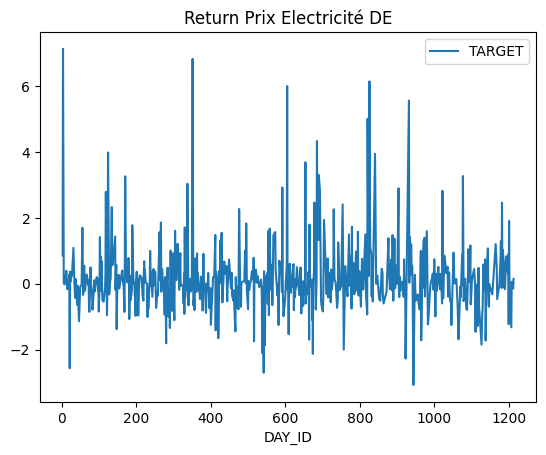

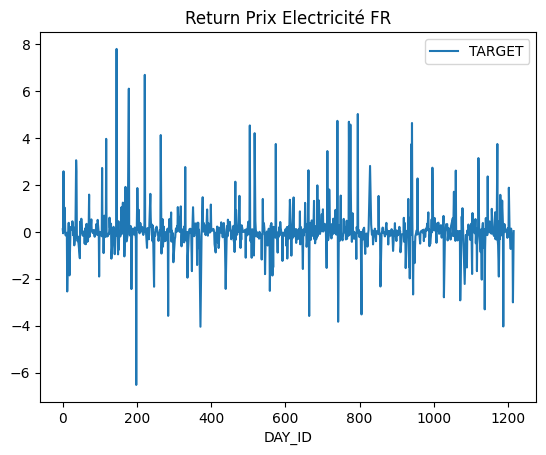

In [25]:
for country in x_train.COUNTRY.unique():
    display(x_train.query(f"COUNTRY == '{country}'")
            .merge(y_train).sort_values(by="DAY_ID")
            .plot(x="DAY_ID", y="TARGET", title=f"Return Prix Electricité {country}"))

# 4) Traitement et création de nouvelles features

## 4.1) Gestion des valeurs manquantes

In [26]:
display(x_train.isna().sum().sort_values(ascending=False))

DE_NET_IMPORT       124
DE_NET_EXPORT       124
FR_RAIN              94
FR_TEMP              94
DE_WIND              94
FR_WIND              94
DE_TEMP              94
DE_RAIN              94
FR_NET_IMPORT        70
FR_NET_EXPORT        70
DE_FR_EXCHANGE       25
FR_DE_EXCHANGE       25
COUNTRY               0
ID                    0
DAY_ID                0
DE_GAS                0
FR_GAS                0
DE_CONSUMPTION        0
FR_CONSUMPTION        0
FR_NUCLEAR            0
DE_NUCLEAR            0
FR_HYDRO              0
DE_HYDRO              0
FR_COAL               0
DE_COAL               0
DE_WINDPOW            0
DE_SOLAR              0
FR_RESIDUAL_LOAD      0
DE_RESIDUAL_LOAD      0
DE_LIGNITE            0
FR_WINDPOW            0
FR_SOLAR              0
GAS_RET               0
COAL_RET              0
CARBON_RET            0
dtype: int64

### 4.1.1) Gestion flux

Logiquement on a :
- DE_FR_EXCHANGE = - FR_DE_EXCHANGE
- DE_NET_EXPORT = - DE_NET_IMPORT
- FR_NET_EXPORT = - FR_NET_IMPORT

In [4]:
flow_pairs = [
    ("DE_FR_EXCHANGE", "FR_DE_EXCHANGE"),
    ("DE_NET_EXPORT", "DE_NET_IMPORT"),
    ("FR_NET_EXPORT", "FR_NET_IMPORT"),
    ]


x_train = x_train.sort_values("DAY_ID")

flux_cols = [c for pair in flow_pairs for c in pair]

display(x_train[["DAY_ID", "COUNTRY"] + flux_cols])

,DAY_ID,COUNTRY,DE_FR_EXCHANGE,FR_DE_EXCHANGE,DE_NET_EXPORT,DE_NET_IMPORT,FR_NET_EXPORT,FR_NET_IMPORT
742,0,FR,-0.079296,0.079296,NaN,NaN,0.650577,-0.650577
1211,1,FR,0.331356,-0.331356,0.405549,-0.405549,0.778627,-0.778627
1468,2,DE,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
1408,2,FR,-1.102015,1.102015,-1.080403,1.080403,0.256736,-0.256736
329,3,FR,-1.051716,1.051716,-1.881881,1.881881,-0.612133,0.612133
...,...,...,...,...,...,...,...,...
986,1212,DE,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
1007,1212,FR,-0.270515,0.270515,-0.137917,0.137917,-0.789824,0.789824
873,1213,FR,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222
1465,1213,DE,-0.456126,0.456126,0.333142,-0.333142,-0.069222,0.069222


### 4.1.2) Gestion NaN Value

#### Median

In [5]:
def apply_median_completion(df, medians, columns):
    df_filled = df.copy()

    for col in columns:
        df_filled[col] = df_filled[col].fillna(
            df_filled["COUNTRY"].map(medians[col])
        )
    return df_filled

# columns with NaN in train
columns_to_fill = x_train.columns[x_train.isna().any()]

# compute medians ONLY from train
train_medians = x_train.groupby("COUNTRY")[columns_to_fill].median()

# fill both datasets using train medians
x_train_median = apply_median_completion(x_train, train_medians, columns_to_fill)
x_test_median = apply_median_completion(x_test, train_medians, columns_to_fill)

## 4.2) Ajout de nouvelles features

Le prix de l'électricité spot (et donc sa variation journalière, qui est ta cible) est déterminé par le coût marginal de production : à chaque instant, on empile les centrales par ordre de coût croissant, et le prix est fixé par la dernière centrale appelée pour satisfaire la demande. Cette logique s'appelle le merit order.

Conséquences directes :

* Plus la demande résiduelle (consommation moins renouvelables, qui sont quasi-gratuites) est élevée, * plus on appelle des centrales chères → prix élevé.
* Plus le coût des combustibles fossiles (gaz, charbon) et du carbone est élevé, plus les centrales marginales coûtent cher → prix élevé.
* Les échanges transfrontaliers redistribuent ces effets entre marchés couplés.

In [6]:
# cible alignée sur ID
x_train_median.sort_values(["COUNTRY", "DAY_ID"], inplace=True)
y_train_clean = y_train.set_index("ID").loc[x_train_median["ID"], "TARGET"]


#### Clippage des rendements aux quantiles

In [7]:
# Clipping des rendements aux quantiles 1% / 99% (calcul sur train, appliqué aux deux)
ret_cols = ['GAS_RET', 'COAL_RET', 'CARBON_RET']
lower = x_train_median[ret_cols].quantile(0.01)
upper = x_train_median[ret_cols].quantile(0.99)

x_train_median[ret_cols] = x_train_median[ret_cols].clip(lower=lower, upper=upper, axis=1)
x_test_median[ret_cols]  = x_test_median[ret_cols].clip(lower=lower, upper=upper, axis=1)

### Ajout des features linéaires

In [8]:
def add_cross_border_flows(df):
    """Échanges transfrontaliers nets entre DE et FR."""
    # Flux net DE→FR (positif = DE exporte vers FR)
    df['NET_FLOW_DE_TO_FR'] = df['DE_FR_EXCHANGE'] - df['FR_DE_EXCHANGE']
    df['DE_NET_BALANCE']    = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_NET_BALANCE']    = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    df['DE_TRADE_BALANCE']  = df['DE_NET_EXPORT']  - df['DE_NET_IMPORT']
    df['FR_TRADE_BALANCE']  = df['FR_NET_EXPORT']  - df['FR_NET_IMPORT']
    return df


def add_marginal_cost_features(df):
    """Coût marginal de production (Merit Order)."""
    # Coût effectif des centrales gaz (coût gaz + taxe carbone)
    df['GAS_CARBON_COST']  = df['GAS_RET']  + df['CARBON_RET']
    # Coût effectif des centrales charbon
    df["COAL_CARBON_COST"] = df['COAL_RET'] + df['CARBON_RET']
    # Index composite du coût fossile (proxy du prix marginal)
    df["FOSSIL_COST_INDEX"] = 0.5 * df["GAS_CARBON_COST"] + 0.5 * df["COAL_CARBON_COST"]
    # Interaction gaz × carbone : signal fort (corr=+0.10 avec TARGET)
    df["GAS_x_CARBON"] = df["GAS_RET"] * df["CARBON_RET"]
    return df


def add_residual_demand_features(df):
    """Demande résiduelle + interactions météo × production par pays."""
    for country in ["DE", "FR"]:
        renewable   = df[f"{country}_SOLAR"] + df[f"{country}_WINDPOW"] + df[f"{country}_HYDRO"]
        consumption = df[f"{country}_CONSUMPTION"]

        # Production totale ENR
        df[f"{country}_RENEWABLE_PROD"]        = renewable
        # Taux de pénétration ENR
        df[f"{country}_RENEWABLE_PENETRATION"] = renewable / consumption
        # Ratio demande résiduelle / consommation totale
        df[f"{country}_RESIDUAL_LOAD_RATIO"]   = df[f"{country}_RESIDUAL_LOAD"] / consumption
        # Prod ENR variable (vent + soleil)
        df[f"{country}_WIND_SOLAR_PROD"]        = df[f"{country}_WINDPOW"] + df[f"{country}_SOLAR"]
        # Température × demande résiduelle (effet froid sur la demande)
        df[f"{country}_TEMP_x_RESIDUAL"]        = df[f"{country}_TEMP"]  * df[f"{country}_RESIDUAL_LOAD"]
        # Vent × production éolienne
        df[f"{country}_WIND_x_WINDPOW"]         = df[f"{country}_WIND"]  * df[f"{country}_WINDPOW"]
        # Pluie × hydraulique
        df[f"{country}_RAIN_x_HYDRO"]           = df[f"{country}_RAIN"]  * df[f"{country}_HYDRO"]
        # Coût gaz pondéré par la production gaz du pays
        df[f"{country}_GAS_COST_x_PROD"]        = df["GAS_RET"]  * df[f"{country}_GAS"]
        # Coût charbon pondéré par la production charbon du pays
        df[f"{country}_COAL_COST_x_PROD"]       = df["COAL_RET"] * df[f"{country}_COAL"]

    return df


def add_thermal_need_features(df):
    """Besoin thermique par pays (ce qui doit être couvert par les fossiles)."""
    # DE : on soustrait nucléaire ET lignite
    df["DE_THERMAL_NEED"] = df["DE_RESIDUAL_LOAD"] - df["DE_NUCLEAR"] - df["DE_LIGNITE"]
    # FR : pas de colonne LIGNITE pour la France
    df["FR_THERMAL_NEED"] = df["FR_RESIDUAL_LOAD"] - df["FR_NUCLEAR"]
    return df


def add_cross_country_features(df):
    """Features cross-pays (signal d'arbitrage DE ↔ FR)."""
    df["RESIDUAL_LOAD_DIFF"]         = df["DE_RESIDUAL_LOAD"]         - df["FR_RESIDUAL_LOAD"]
    df["RENEWABLE_DIFF"]             = df["DE_RENEWABLE_PROD"]        - df["FR_RENEWABLE_PROD"]
    df["TEMP_DIFF"]                  = df["DE_TEMP"]                  - df["FR_TEMP"]
    df["NUCLEAR_DIFF"]               = df["DE_NUCLEAR"]               - df["FR_NUCLEAR"]
    df["RENEWABLE_PENETRATION_DIFF"] = df["DE_RENEWABLE_PENETRATION"] - df["FR_RENEWABLE_PENETRATION"]
    # Écart de consommation brute DE vs FR (corr=-0.06 avec TARGET)
    df["CONSUMPTION_DIFF"]           = df["DE_CONSUMPTION"]           - df["FR_CONSUMPTION"]
    return df


def add_country_encoding(df):
    """One-hot encoding de la variable COUNTRY."""
    df['COUNTRY_DE'] = (df['COUNTRY'] == 'DE').astype(int)
    df['COUNTRY_FR'] = (df['COUNTRY'] == 'FR').astype(int)
    
    return df


def add_physical_features(df):
    """
    Pipeline complet de feature engineering physique.
    Appelle toutes les sous-fonctions dans l'ordre.
    """
    df = df.copy()
    df = add_cross_border_flows(df)
    df = add_marginal_cost_features(df)
    df = add_residual_demand_features(df)
    df = add_thermal_need_features(df)
    df = add_cross_country_features(df)
    df = add_country_encoding(df)
    return df

x_train_median = add_physical_features(x_train_median)
x_test_median  = add_physical_features(x_test_median)

### Ajout de features polynomiales

In [ ]:
# # Top 15 features selon permutation importance (en excluant les flags pays)
# top_features = [f for f in imp_df.head(15)['feature'].tolist()
#                 if f not in ['COUNTRY_DE', 'COUNTRY_FR']]

# # Creation des features polynomiales de degre 2 (inclut interactions + carres)
# poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
# X_poly_train = poly.fit_transform(x_train_median[top_features])
# X_poly_test  = poly.transform(x_test_median[top_features])

# # Noms des nouvelles features pour tracabilite
# poly_names = poly.get_feature_names_out(top_features)

# # DataFrame enrichi : features originales selectionnees + features polynomiales
# # On garde ID comme index et on preserve COUNTRY_DE/COUNTRY_FR pour cv_score_par_pays
# X_poly_train_df = pd.DataFrame(X_poly_train, columns=poly_names, index=x_train_median.index)
# X_poly_test_df  = pd.DataFrame(X_poly_test,  columns=poly_names, index=x_test_median.index)

# # On supprime les doublons : les features originales sont deja presentes sous leur nom simple
# # dans poly_names (degre 1), donc on garde uniquement les nouvelles (interactions + carres)
# new_poly_cols = [c for c in poly_names if c not in top_features]

# X_enriched_train = pd.concat([
#     x_train_median.set_index("ID")[selected_features_perm],
#     X_poly_train_df.set_index(x_train_median["ID"])[new_poly_cols],
# ], axis=1)

# X_enriched_test = pd.concat([
#     x_test_median.set_index("ID")[selected_features_perm],
#     X_poly_test_df.set_index(x_test_median["ID"])[new_poly_cols],
# ], axis=1)

NameError: name 'imp_df' is not defined

## 4.3) Normalisation des données

Les données, étant dans des unités différentes et de variations différentes, il convient de les normaliser afin de pouvoir les comparer par la suite.

In [16]:
x_train_median.columns

Index(['ID', 'DAY_ID', 'COUNTRY', 'DE_CONSUMPTION', 'FR_CONSUMPTION',
       'DE_FR_EXCHANGE', 'FR_DE_EXCHANGE', 'DE_NET_EXPORT', 'FR_NET_EXPORT',
       'DE_NET_IMPORT', 'FR_NET_IMPORT', 'DE_GAS', 'FR_GAS', 'DE_COAL',
       'FR_COAL', 'DE_HYDRO', 'FR_HYDRO', 'DE_NUCLEAR', 'FR_NUCLEAR',
       'DE_SOLAR', 'FR_SOLAR', 'DE_WINDPOW', 'FR_WINDPOW', 'DE_LIGNITE',
       'DE_RESIDUAL_LOAD', 'FR_RESIDUAL_LOAD', 'DE_RAIN', 'FR_RAIN', 'DE_WIND',
       'FR_WIND', 'DE_TEMP', 'FR_TEMP', 'GAS_RET', 'COAL_RET', 'CARBON_RET',
       'NET_FLOW_DE_TO_FR', 'DE_NET_BALANCE', 'FR_NET_BALANCE',
       'DE_TRADE_BALANCE', 'FR_TRADE_BALANCE', 'GAS_CARBON_COST',
       'COAL_CARBON_COST', 'FOSSIL_COST_INDEX', 'GAS_x_CARBON',
       'DE_RENEWABLE_PROD', 'DE_RENEWABLE_PENETRATION',
       'DE_RESIDUAL_LOAD_RATIO', 'DE_WIND_SOLAR_PROD', 'DE_TEMP_x_RESIDUAL',
       'DE_WIND_x_WINDPOW', 'DE_RAIN_x_HYDRO', 'DE_GAS_COST_x_PROD',
       'DE_COAL_COST_x_PROD', 'FR_RENEWABLE_PROD', 'FR_RENEWABLE_PENETRATION',
      

In [9]:
index_cols = ["ID", "DAY_ID"]
do_not_normalize= index_cols + ["COUNTRY", "COUNTRY_DE","COUNTRY_FR"]
cols_to_normalize = [c for c in x_train_median.columns if c not in do_not_normalize]

qt = QuantileTransformer(output_distribution='normal', random_state=42)

# On applique la transfo sur les colonnes continues uniquement
x_train_median[cols_to_normalize] = qt.fit_transform(x_train_median[cols_to_normalize])
x_test_median[cols_to_normalize]  = qt.transform(x_test_median[cols_to_normalize])

## 4.4) Sélection de variable : Spearman corrélation + Permutation Importance

In [10]:
# Scorer Spearman pour la cross validation
spearman_scorer = make_scorer(
    lambda y_true, y_pred: spearmanr(y_true, y_pred).correlation,
    greater_is_better=True
)


# GroupKFold sur DAY_ID : DE et FR d'un même jour restent dans le même fold
groups = x_train_median['DAY_ID'].values
gkf = GroupKFold(n_splits=5)

feature_cols = [c for c in x_train_median.columns if c not in index_cols + ["COUNTRY"]]
X_cv = x_train_median.set_index("ID")[feature_cols]
y_cv = y_train_clean

# Baseline : score avec toutes les features
baseline = cross_val_score(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    X_cv, y_cv,
    cv=list(gkf.split(X_cv, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1
)

print(f"Toutes features --> Spearman CV : {np.mean(baseline):.4f} ± {np.std(baseline):.4f}")


# Sélection des variables par permutation importance
# On entraine le modele sur tout le train, puis on mesure la perte de score
# quand on melange aleatoirement chaque feature une par une
# les 300 arbres c'est un peu arbitraire mais c'est juste pour prendre large
selector_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
selector_model.fit(X_cv, y_cv)

perm_imp = permutation_importance(
    selector_model, X_cv, y_cv,
    scoring=spearman_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_imp.importances_mean,
    'importance_std':  perm_imp.importances_std,
}).sort_values('importance_mean', ascending=False)

print(imp_df.to_string(index=False))

# On garde les features qui contribuent positivement au score
selected_features_perm = imp_df[imp_df['importance_mean'] > 0]['feature'].tolist()
print(f"\nFeatures retenues : {len(selected_features_perm)}/{len(feature_cols)}")

Toutes features --> Spearman CV : 0.1946 ± 0.0510
                   feature  importance_mean  importance_std
                COUNTRY_FR         0.097519        0.004177
                DE_WINDPOW         0.091984        0.007125
                COUNTRY_DE         0.088428        0.004441
        FR_WIND_SOLAR_PROD         0.035207        0.002890
          DE_RESIDUAL_LOAD         0.032202        0.002843
        RESIDUAL_LOAD_DIFF         0.031266        0.002325
                DE_LIGNITE         0.024925        0.003933
        DE_WIND_SOLAR_PROD         0.024647        0.003089
         FR_WIND_x_WINDPOW         0.022685        0.003201
        FR_GAS_COST_x_PROD         0.022023        0.002161
                FR_WINDPOW         0.018485        0.002710
                   DE_WIND         0.017470        0.001868
                    FR_GAS         0.017199        0.002945
           DE_THERMAL_NEED         0.017014        0.003152
                   DE_RAIN         0.016262       

Utilisation de GroupKFold:
Sklearn découpe les 1494 lignes en 5 paquets (folds) en respectant une règle : toutes les lignes partageant le même DAY_ID restent dans le même fold. Comme on a deux lignes par jour (une DE, une FR), ça garantit que la ligne FR du jour 42 n'est jamais en train pendant que la ligne DE du jour 42 est en validation. Sinon le modèle verrait l'info météo/énergétique du jour en train (via l'autre pays) et tricherait.

# 5) Sélection du modèle

Nous allons donc tester plusieurs modèles sur nos données d'entrainement pour trouver celui qui maximiser la corrélation de Spearman. Nous allons nous concentrer sur les modèles de régression.

In [13]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(random_state=42),
    'Random Forest Regression': RandomForestRegressor(random_state=42),
    'Gradient Boosting Regression': GradientBoostingRegressor(random_state=42),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# modèle de boosting sans paramétrage
models['LightGBM'] = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
)
models['XGBoost'] = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

# mode series
y_test_clean = y_test.set_index("ID")["TARGET"]

# Comparer les modèles sur ces features
X_sel = x_train_median.set_index("ID")[selected_features_perm]

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_sel, y_cv,
        cv=list(gkf.split(X_sel, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

Features utilisées : ['COUNTRY_FR', 'DE_WINDPOW', 'COUNTRY_DE', 'FR_WIND_SOLAR_PROD', 'DE_RESIDUAL_LOAD', 'RESIDUAL_LOAD_DIFF', 'DE_LIGNITE', 'DE_WIND_SOLAR_PROD', 'FR_WIND_x_WINDPOW', 'FR_GAS_COST_x_PROD', 'FR_WINDPOW', 'DE_WIND', 'FR_GAS', 'DE_THERMAL_NEED', 'DE_RAIN', 'DE_HYDRO', 'DE_SOLAR', 'FR_WIND', 'DE_RAIN_x_HYDRO', 'GAS_RET', 'DE_WIND_x_WINDPOW', 'FR_RENEWABLE_PROD', 'FR_RESIDUAL_LOAD_RATIO', 'CONSUMPTION_DIFF', 'CARBON_RET', 'GAS_CARBON_COST', 'DE_GAS', 'NUCLEAR_DIFF', 'FR_CONSUMPTION', 'GAS_x_CARBON', 'FR_TEMP_x_RESIDUAL', 'DE_COAL', 'TEMP_DIFF', 'DE_NET_IMPORT', 'FR_COAL', 'FOSSIL_COST_INDEX', 'DE_RENEWABLE_PENETRATION', 'DE_TEMP', 'DE_COAL_COST_x_PROD', 'DE_RENEWABLE_PROD', 'FR_COAL_COST_x_PROD', 'DE_GAS_COST_x_PROD', 'FR_SOLAR', 'FR_THERMAL_NEED', 'FR_DE_EXCHANGE', 'DE_TEMP_x_RESIDUAL', 'DE_NUCLEAR', 'FR_RAIN_x_HYDRO', 'FR_HYDRO', 'FR_RENEWABLE_PENETRATION', 'DE_CONSUMPTION', 'FR_RAIN', 'RENEWABLE_DIFF', 'FR_TEMP', 'RENEWABLE_PENETRATION_DIFF', 'COAL_RET', 'COAL_CARBON_CO

,model,spearman_mean,spearman_std
10,CatBoost,0.219040,0.035977
1,Ridge Regression,0.213688,0.032183
2,Lasso Regression,0.211245,0.027059
3,ElasticNet,0.210081,0.023614
4,Support Vector Regression,0.189873,0.045734
11,XGBoost,0.181629,0.035907
6,Random Forest Regression,0.180610,0.046964
7,Gradient Boosting Regression,0.170138,0.019824
0,Linear Regression,0.160712,0.058116
9,LightGBM,0.159989,0.041701


Utilisation du cross val score:
Sklearn boucle sur les 5 splits, et pour chacun :

- Clone le modèle (pour repartir vierge, sans fuite entre folds).
- Appelle model.fit(X_sel.iloc[train_idx], y_cv.iloc[train_idx]) → entraîne sur 4 folds.
- Appelle model.predict(X_sel.iloc[val_idx]) → prédit sur le fold restant.
- Applique le scorer : spearmanr(y_cv.iloc[val_idx], predictions).correlation → un nombre.

Nous remarquons que Catboost, Ridge Regression ou Lasso et ElasticNet affichent un score au dessus de 21%. Nous allons donc dans un premier temps nous concentrer sur ces modèles.

### Avec features polynomiales

In [ ]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    'Lasso Regression': LassoCV(alphas=np.logspace(-3, 3, 50), cv=10, max_iter=10000, n_jobs=-1),
    'ElasticNet': ElasticNetCV(
        alphas=np.logspace(-3, 3, 50),
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
        cv=10,
        max_iter=10000,
        n_jobs=-1
    ),
    'Support Vector Regression': SVR(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'Gradient Boosting Regression': GradientBoostingRegressor(),
    'K-Neighbors Regression': KNeighborsRegressor()
}

# modèle de boosting sans paramétrage
models['LightGBM'] = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1,
)
models['CatBoost'] = CatBoostRegressor(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0,
)
models['XGBoost'] = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

# Comparer les modèles sur ces features
X_sel_enriched = X_enriched_train.copy()

res = []
for name, mod in models.items():
    print(name)
    cv_scores = cross_val_score(
        mod, X_sel_enriched, y_cv,
        cv=list(gkf.split(X_sel_enriched, y_cv, groups=groups)),
        scoring=spearman_scorer,
        n_jobs=-1
    )
    res.append({
        'model': name,
        'spearman_mean': np.mean(cv_scores),
        'spearman_std':  np.std(cv_scores),
    })

res_df = pd.DataFrame(res).sort_values('spearman_mean', ascending=False)
res_df[['model', 'spearman_mean', 'spearman_std']]

Linear Regression
Ridge Regression
Lasso Regression
ElasticNet
Support Vector Regression
Decision Tree Regression
Random Forest Regression
Gradient Boosting Regression
K-Neighbors Regression
LightGBM
CatBoost
XGBoost


,model,spearman_mean,spearman_std
4,Support Vector Regression,0.173598,0.050223
10,CatBoost,0.171905,0.037204
3,ElasticNet,0.166925,0.037721
6,Random Forest Regression,0.166876,0.031711
1,Ridge Regression,0.164478,0.048087
7,Gradient Boosting Regression,0.163190,0.027938
2,Lasso Regression,0.160423,0.040017
11,XGBoost,0.143158,0.016763
9,LightGBM,0.129672,0.049588
8,K-Neighbors Regression,0.118583,0.019465


## 5.2) CatBoost Model

#### Optimisation des hyperparamètres avec Optuna

Optuna est une bibliothèque d'optimisation d'hyperparamètres qui repose sur un algorithme appelé **TPE** (*Tree-structured Parzen Estimator*). Contrairement à une recherche exhaustive (`GridSearchCV`) qui teste toutes les combinaisons d'une grille prédéfinie, ou à une recherche aléatoire (`RandomizedSearchCV`) qui tire des combinaisons au hasard, Optuna apprend au fur et à mesure des essais déjà effectués. Après chaque essai, l'algorithme modélise la distribution des hyperparamètres ayant donné de bons résultats et celle des hyperparamètres ayant donné de mauvais résultats, puis échantillonne préférentiellement dans les zones prometteuses de l'espace de recherche. Cette approche bayésienne permet d'atteindre un optimum comparable à une recherche exhaustive avec un nombre d'essais bien plus faible, typiquement 3 à 5 fois moins que pour une recherche aléatoire.

Concrètement, on définit une fonction *objective* qui prend un objet `trial` en argument. Cet objet permet de suggérer des valeurs pour chaque hyperparamètre via des méthodes comme `suggest_int`, `suggest_float` (avec une option `log=True` pour les échelles logarithmiques) ou `suggest_categorical`. La fonction retourne un score à maximiser ou minimiser — dans notre cas, la corrélation de Spearman moyenne obtenue par cross-validation avec `GroupKFold` sur `DAY_ID`. Optuna appelle cette fonction `n_trials` fois et conserve la meilleure combinaison trouvée, accessible via `study.best_params`. La bibliothèque offre également un mécanisme de *pruning* qui permet d'interrompre prématurément les essais dont les premiers folds indiquent déjà une performance médiocre, ce qui réduit encore le temps de calcul.

In [22]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """Optimisation des hyperparametres de CatBoost avec early stopping et pruning."""

    params = {
        'iterations': trial.suggest_int('cat_iterations', 200, 2000),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.15, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1e-2, 30.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 1, 50),
        # early_stopping_rounds : arret si pas d'amelioration pendant 50 iterations
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }

    # Cross validation manuelle pour pouvoir rapporter chaque fold a Optuna (pruning)
    gkf_local = GroupKFold(n_splits=5)
    scores = []
    for fold_idx, (tr_idx, va_idx) in enumerate(gkf_local.split(X_sel, y_cv, groups=groups)):
        X_tr, X_va = X_sel.iloc[tr_idx], X_sel.iloc[va_idx]
        y_tr, y_va = y_cv.iloc[tr_idx], y_cv.iloc[va_idx]

        model = CatBoostRegressor(**params)
        # eval_set alimente l'early stopping : CatBoost surveille l'erreur sur ce jeu
        # et arrete quand elle ne s'ameliore plus
        model.fit(X_tr, y_tr, eval_set=(X_va, y_va), verbose=0)
        pred = model.predict(X_va)
        scores.append(spearmanr(y_va, pred).correlation)

        # On rapporte le score moyen courant a Optuna apres chaque fold
        trial.report(np.mean(scores), step=fold_idx)
        # Si le trial est juge peu prometteur compare aux precedents, on l'interrompt
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(scores)

# Configuration du pruner
# n_startup_trials=10 : on laisse passer les 10 premiers essais pour etablir une reference
# n_warmup_steps=2 : on attend au moins 2 folds avant de pouvoir pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=pruner,
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Meilleur Spearman CV : {study.best_value:.4f}")
print(f"Trials completes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Trials prunes : {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print("Meilleurs hyperparametres :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Meilleur Spearman CV : 0.2466
Trials completes : 38
Trials prunes : 12
Meilleurs hyperparametres :
  cat_iterations: 1774
  cat_learning_rate: 0.006997953267735746
  cat_depth: 5
  cat_l2_leaf_reg: 0.10411323200654027
  cat_bagging_temperature: 0.4950149033351272
  cat_random_strength: 0.024912417260024747
  cat_border_count: 153
  cat_min_data_in_leaf: 7


***Early stopping***
L'early stopping (arrêt anticipé) consiste à interrompre l'entraînement d'un modèle de boosting avant d'avoir construit tous les arbres demandés, dès que les performances sur un jeu de validation cessent de s'améliorer. À chaque nouvel arbre ajouté, le modèle évalue son erreur sur un petit échantillon mis de côté ; si cette erreur ne diminue plus pendant un nombre fixé d'itérations consécutives (paramètre early_stopping_rounds), l'entraînement s'arrête et le modèle conserve sa meilleure configuration. Cela évite le surapprentissage lié à un iterations surdimensionné et accélère fortement chaque essai : avec un budget maximal de 2000 arbres, le modèle en construit souvent 300-500 seulement avant de s'arrêter, soit 4 à 6 fois plus rapidement. On choisit typiquement une valeur de 50 pour early_stopping_rounds : suffisamment large pour absorber les fluctuations normales de l'erreur de validation, mais suffisamment stricte pour ne pas laisser tourner inutilement.

***Pruning***

Le pruning est un mécanisme propre à Optuna qui interrompt prématurément les essais peu prometteurs sans attendre que les 5 folds de la cross-validation soient tous calculés. Après chaque fold, on rapporte le score intermédiaire à Optuna via trial.report(...), puis on appelle trial.should_prune() qui compare ce score à la distribution des essais précédents au même stade. Si le score est clairement en-dessous, on lève optuna.TrialPruned et on passe à l'essai suivant. On utilise ici le MedianPruner, qui coupe tout essai dont le score intermédiaire est inférieur à la médiane des essais précédents au même fold — c'est le choix par défaut le plus robuste, car il ne fait aucune hypothèse sur la distribution des scores. Le paramètre n_startup_trials=10 demande à Optuna de laisser passer les 10 premiers essais sans pruning pour constituer une base de comparaison fiable, et n_warmup_steps=2 exige qu'au moins 2 folds soient évalués avant de considérer un essai pour élimination (sinon on couperait sur la base d'un seul fold, trop bruité). Alternative : le HyperbandPruner est plus agressif et convient mieux aux très gros budgets (500+ trials) ; sur 50-100 trials le MedianPruner est plus sûr.

### CatBoost par pays

In [23]:
def objective_cat_separe(trial):
    """Optimise CatBoost en mode separe FR/DE via cv_score_par_pays."""
    params = {
        # Plages resserrees vers plus de regularisation (moins de donnees par pays)
        'iterations': trial.suggest_int('cat_iterations', 200, 1500),
        'learning_rate': trial.suggest_float('cat_learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('cat_depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('cat_l2_leaf_reg', 1.0, 50.0, log=True),
        'bagging_temperature': trial.suggest_float('cat_bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('cat_random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('cat_border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('cat_min_data_in_leaf', 5, 50),
        'early_stopping_rounds': 50,
        'random_seed': 42,
        'verbose': 0,
    }
    factory = lambda: CatBoostRegressor(**params)
    mean_score, _ = cv_score_par_pays(factory, X_sel, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_sep = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_sep.optimize(objective_cat_separe, n_trials=50, show_progress_bar=True)

print(f"CatBoost separe tune --> Spearman CV : {study_sep.best_value:.4f}")
print("Meilleurs hyperparametres :")
for k, v in study_sep.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

CatBoost separe tune --> Spearman CV : 0.2404
Meilleurs hyperparametres :
  cat_iterations: 830
  cat_learning_rate: 0.014664451919388472
  cat_depth: 3
  cat_l2_leaf_reg: 28.381814325217164
  cat_bagging_temperature: 0.33498154516230666
  cat_random_strength: 5.3067931414898135
  cat_border_count: 97
  cat_min_data_in_leaf: 23


## 5.3) ElasticNet Model

In [17]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score, GridSearchCV

param_grid = {
    'alpha'   : [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.2, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
}

gs = GridSearchCV(
    ElasticNet(max_iter=100000),
    param_grid,
    cv=list(gkf.split(X_sel, y_cv, groups=groups)),
    scoring=spearman_scorer,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs.fit(X_sel, y_cv)

print(f"Meilleurs params : {gs.best_params_}")
print(f"Meilleur score   : {gs.best_score_:.4f}")

best_en = ElasticNet(**gs.best_params_, max_iter=100000)
fold_scores = []
for tr, val in gkf.split(X_sel, y_cv, groups=groups):
    best_en.fit(X_sel.iloc[tr], y_cv.iloc[tr])
    pred = best_en.predict(X_sel.iloc[val])
    fold_scores.append(spearmanr(y_cv.iloc[val], pred).correlation)

print(f"\nScores par fold : {[f'{s:.4f}' for s in fold_scores]}")
print(f"Moyenne : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

coef_df = pd.DataFrame({
    'feature': X_sel.columns,
    'coef'   : gs.best_estimator_.coef_,
}).assign(abs_coef=lambda df: df['coef'].abs()) \
  .sort_values('abs_coef', ascending=False) \
  .query('coef != 0') \
  .drop(columns='abs_coef')

print(f"\nFeatures non nulles : {len(coef_df)}/{len(X_sel.columns)}")
print(coef_df.head(15).to_string(index=False))


Fitting 5 folds for each of 48 candidates, totalling 240 fits


/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
/var/folders/5q/kk1fbxc906b97fnm87mtg7m80000gn/T/ipykernel_78853/1645198674.py:3: ConstantInputWarning: An input array i

Meilleurs params : {'alpha': 0.1, 'l1_ratio': 0.5}
Meilleur score   : 0.2146

Scores par fold : ['0.2133', '0.2583', '0.2150', '0.1866', '0.1998']
Moyenne : 0.2146 ± 0.0241

Features non nulles : 10/69
                 feature      coef
              FR_WINDPOW -0.031834
      FR_WIND_SOLAR_PROD -0.024773
            GAS_x_CARBON  0.023913
      DE_WIND_SOLAR_PROD -0.022305
           DE_NET_IMPORT  0.021162
          DE_NET_BALANCE -0.021132
           DE_NET_EXPORT -0.021095
        DE_TRADE_BALANCE -0.021068
        CONSUMPTION_DIFF -0.015075
DE_RENEWABLE_PENETRATION -0.007490


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/model_selection/_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.16239473 0.16259395 0.16271104 0.16274006 0.16325182 0.16357202
 0.16360633 0.16370846 0.16832454 0.16969398 0.17089003 0.17305237
 0.17594112 0.17846849 0.17887463 0.17903587 0.18715086 0.19083735
 0.19124291 0.19439463 0.19859041 0.20245563 0.20288816 0.20355938
 0.2097147  0.21291829 0.21355537 0.21457259 0.20765389 0.19851474
 0.19578655 0.19407942 0.19492765        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan]
  warnings.warn(


In [ ]:
top_features_en = coef_df['feature'].tolist()

ridge_top = cross_val_score(
    RidgeCV(alphas=np.logspace(-3, 3, 50), cv=10),
    X_sel[top_features_en], y_cv,
    cv=list(gkf.split(X_sel[top_features_en], y_cv, groups=groups)),
    scoring=spearman_scorer, n_jobs=-1
)
print(f"Ridge (10 features) : {np.mean(ridge_top):.4f} ± {np.std(ridge_top):.4f}")


Ridge (10 features) : 0.2293 ± 0.0263


## 5.4) Ridge Regression Model

### Test en séparant les pays

In [ ]:
# Entrainement separe FR / DE puis concatenation des predictions

def cv_score_par_pays(model_factory, X, y, groups, country_flag):
    """Evalue un modele entraine separement sur DE et FR via GroupKFold.
    Compatible avec n'importe quelle famille de modele (lineaire, boosting, etc.)."""
    scores = []
    gkf_local = GroupKFold(n_splits=5)
    for tr_idx, va_idx in gkf_local.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))
        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val
            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue
            m = model_factory()
            m.fit(X_tr[mask_tr].drop(columns=['COUNTRY_DE', 'COUNTRY_FR']),
                  y_tr[mask_tr])
            pred_va[mask_va.values] = m.predict(
                X_va[mask_va].drop(columns=['COUNTRY_DE', 'COUNTRY_FR'])
            )
        scores.append(spearmanr(y_va, pred_va).correlation)
    return np.mean(scores), np.std(scores)

# Factory Ridge : chaque appel instancie un nouveau RidgeCV qui tunera
# automatiquement son alpha par cross validation interne sur le sous-ensemble pays
factory_ridge = lambda: RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)

mean_sep, std_sep = cv_score_par_pays(
    factory_ridge, X_sel, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge separe FR/DE --> Spearman CV : {mean_sep:.4f} +/- {std_sep:.4f}")

Ridge separe FR/DE --> Spearman CV : 0.2559 +/- 0.0344


### Ajout du rang gaussien sur la cible

Factory Ridge avec transformation de la cible en rangs gaussiens. Comme la métrique est Spearman (basée sur les rangs), cela aligne la loss du modèle avec la métrique d'évaluation.

In [25]:
factory_ridge_qt = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),  # borne haute pour eviter les warnings sur petits echantillons
        random_state=42,
    ),
)

mean_sep_qt, std_sep_qt = cv_score_par_pays(
    factory_ridge_qt, X_sel, y_cv, groups, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) separe FR/DE --> Spearman CV : {mean_sep_qt:.4f} +/- {std_sep_qt:.4f}")

Ridge + QT(y) separe FR/DE --> Spearman CV : 0.2715 +/- 0.0157


### Avec les features polynomiales

In [28]:

# Grille d'alphas elargie : plus de features --> plus de regularisation necessaire
factory_ridge_poly = lambda: TransformedTargetRegressor(
    regressor=RidgeCV(alphas=np.logspace(-3, 5, 100), cv=10),
    transformer=QuantileTransformer(
        output_distribution='normal',
        n_quantiles=min(500, 600),
        random_state=42,
    ),
)

# groups doit etre reconstruit dans le meme ordre que X_enriched_train
groups_enriched = x_train_median.set_index("ID").loc[X_enriched_train.index, "DAY_ID"].values

mean_poly, std_poly = cv_score_par_pays(
    factory_ridge_poly, X_enriched_train, y_cv, groups_enriched, 'COUNTRY_DE'
)
print(f"Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : {mean_poly:.4f} +/- {std_poly:.4f}")
print(f"Nombre de features : {X_enriched_train.shape[1]}")

Ridge + QT(y) + Poly degre 2 separe FR/DE --> Spearman CV : 0.2520 +/- 0.0306
Nombre de features : 160


### Kernel avec un Ridge

In [30]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_krr(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1.0, log=True)

    factory = lambda: TransformedTargetRegressor(
        regressor=KernelRidge(alpha=alpha, kernel='rbf', gamma=gamma),
        transformer=QuantileTransformer(
            output_distribution='normal',
            n_quantiles=min(500, 600),
            random_state=42,
        ),
    )
    mean_score, _ = cv_score_par_pays(factory, X_sel, y_cv, groups, 'COUNTRY_DE')
    return mean_score

study_krr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study_krr.optimize(objective_krr, n_trials=70, show_progress_bar=True)

print(f"KernelRidge tune --> Spearman CV : {study_krr.best_value:.4f}")
print(f"Meilleurs params : {study_krr.best_params}")

  0%|          | 0/70 [00:00<?, ?it/s]

KernelRidge tune --> Spearman CV : 0.2745
Meilleurs params : {'alpha': 0.4849429484585504, 'gamma': 0.00013176818695587726}


### Soumission

In [ ]:
# ===== Soumission finale : KernelRidge RBF séparé FR / DE + check CV =====

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.model_selection import GroupKFold
from sklearn.kernel_ridge import KernelRidge
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import QuantileTransformer

# 1) paramètres optimaux Optuna
best_alpha = study_krr.best_params["alpha"]
best_gamma = study_krr.best_params["gamma"]

print("Best params Optuna")
print({"alpha": best_alpha, "gamma": best_gamma})

# 2) factory du modèle
def make_krr():
    return TransformedTargetRegressor(
        regressor=KernelRidge(alpha=best_alpha, kernel="rbf", gamma=best_gamma),
        transformer=QuantileTransformer(
            output_distribution="normal",
            n_quantiles=min(500, len(X_sel)),
            random_state=42,
        ),
    )

# 3) CV Spearman séparé par pays
def cv_score_par_pays(model_factory, X, y, groups, country_flag="COUNTRY_DE", n_splits=5):
    scores = []
    gkf = GroupKFold(n_splits=n_splits)

    for tr_idx, va_idx in gkf.split(X, y, groups=groups):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        pred_va = np.zeros(len(va_idx))

        for flag_val in [0, 1]:
            mask_tr = X_tr[country_flag] == flag_val
            mask_va = X_va[country_flag] == flag_val

            if mask_tr.sum() == 0 or mask_va.sum() == 0:
                continue

            model = model_factory()
            model.fit(
                X_tr.loc[mask_tr].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
                y_tr.loc[mask_tr]
            )
            pred_va[mask_va.values] = model.predict(
                X_va.loc[mask_va].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
            )

        scores.append(spearmanr(y_va, pred_va).correlation)

    return np.array(scores)

cv_scores = cv_score_par_pays(make_krr, X_sel, y_cv, groups, country_flag="COUNTRY_DE", n_splits=5)
print(f"KernelRidge RBF séparé FR/DE --> CV Spearman : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("Fold scores :", np.round(cv_scores, 4))

# 4) préparation test
X_test_sel = x_test_median.set_index("ID")[selected_features_perm].copy()

# 5) fit final sur tout le train puis prédiction test séparée FR / DE
test_pred = np.zeros(len(X_test_sel))

for flag_val in [0, 1]:
    mask_train = X_sel["COUNTRY_DE"] == flag_val
    mask_test = X_test_sel["COUNTRY_DE"] == flag_val

    model = make_krr()
    model.fit(
        X_sel.loc[mask_train].drop(columns=["COUNTRY_DE", "COUNTRY_FR"]),
        y_cv.loc[mask_train]
    )
    test_pred[mask_test.values] = model.predict(
        X_test_sel.loc[mask_test].drop(columns=["COUNTRY_DE", "COUNTRY_FR"])
    )

# 6) CSV de soumission
submission = pd.DataFrame({
    "ID": X_test_sel.index,
    "TARGET": test_pred
}).reset_index(drop=True)

submission.to_csv("submission_krr_rbf_sep.csv", index=False)

print("\nAperçu submission :")
display(submission.head())
print("Shape :", submission.shape)
print("Fichier sauvegardé : submission_krr_rbf_sep.csv")

# 6) Benchmark

Le benchmark pour ce challenge consiste en une simple régression linéaire, après un léger nettoyage des données : les valeurs manquantes (NaN) ont été remplacées par des zéros et la colonne COUNTRY a été supprimée - en d'autres termes, nous avons utilisé un modèle identique pour la France et l'Allemagne.

Le score public obtenu pour ce benchmark est de 15.86%.

**Mesure de performance demandée** : Corrélation de Spearman

In [20]:
lr = LinearRegression()

x_train_clean = x_train.drop(['COUNTRY'], axis=1).fillna(0)
y_train_clean = y_train.set_index('ID').loc[x_train_clean['ID'], 'TARGET']

lr.fit(x_train_clean, y_train_clean)

output_train = lr.predict(x_train_clean)

def metric_train(output):
    return spearmanr(output, y_train_clean).correlation

print("Corrélation (Spearman) pour les données d'entrainement : {:.1f}%".format(100 * metric_train(output_train) ))

Corrélation (Spearman) pour les données d'entrainement : 27.9%


# 7) Modèle non supervisé

Avec une méthode non supervisée, nous allons essayer de trouver différents clusters. Pour cela, nous allons tout d'abord effectuer une visualisation de nos données avec une PCA et un t-SNE. Suite à cela, nous regarderons un modèle KMeans, puis Gaussian Mixture Model pour finir avec un Hidden Markov Model.

## 7.1) PCA

Nous commençons par appliquer une PCA sur nos données pour réduire le nombre de dimensions. 

Variance expliquée par les 3 premières composantes :
PC1 : 17.9%, PC2 : 11.5%, PC3 : 9.8%
Nombre de composantes pour 80% de variance : 17
Nombre de composantes pour 95% de variance : 32


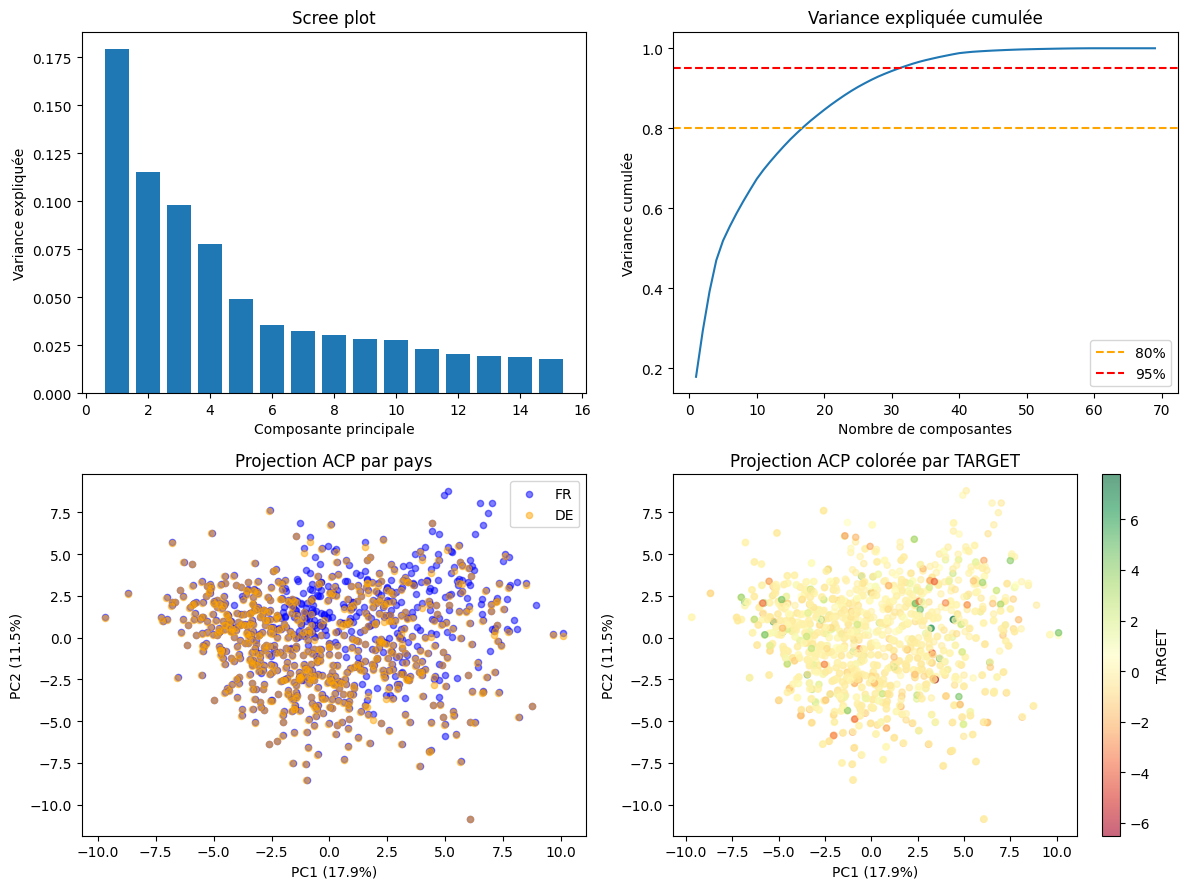

In [31]:
# ACP sur les features sélectionnées
X_pca = X_sel.copy()
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_pca.index, 'COUNTRY']
target = y_cv.loc[X_pca.index].values

pca = PCA()
X_proj = pca.fit_transform(X_pca)

variance = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance)

print("Variance expliquée par les 3 premières composantes :")
print(f"PC1 : {variance[0]:.1%}, PC2 : {variance[1]:.1%}, PC3 : {variance[2]:.1%}")
print(f"Nombre de composantes pour 80% de variance : {np.argmax(variance_cumulee >= 0.80) + 1}")
print(f"Nombre de composantes pour 95% de variance : {np.argmax(variance_cumulee >= 0.95) + 1}")


fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Screen plot
axes[0, 0].bar(range(1, 16), variance[:15])
axes[0, 0].set_xlabel("Composante principale")
axes[0, 0].set_ylabel("Variance expliquée")
axes[0, 0].set_title("Scree plot")

# Variance cumulée
axes[0, 1].plot(range(1, len(variance_cumulee)+1), variance_cumulee)
axes[0, 1].axhline(0.80, color='orange', linestyle='--', label='80%')
axes[0, 1].axhline(0.95, color='red', linestyle='--', label='95%')
axes[0, 1].set_xlabel("Nombre de composantes")
axes[0, 1].set_ylabel("Variance cumulée")
axes[0, 1].set_title("Variance expliquée cumulée")
axes[0, 1].legend()

# Projection par pays
for pays, couleur in [('FR', 'blue'), ('DE', 'orange')]:
    mask = country.values == pays
    axes[1, 0].scatter(X_proj[mask, 0], X_proj[mask, 1], c=couleur, alpha=0.5, s=20, label=pays)
axes[1, 0].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 0].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 0].set_title('Projection ACP par pays')
axes[1, 0].legend()

# Projection colorée par TARGET
sc = axes[1, 1].scatter(X_proj[:, 0], X_proj[:, 1], c=target, cmap='RdYlGn', alpha=0.6, s=20)
plt.colorbar(sc, ax=axes[1, 1], label='TARGET')
axes[1, 1].set_xlabel(f'PC1 ({variance[0]:.1%})')
axes[1, 1].set_ylabel(f'PC2 ({variance[1]:.1%})')
axes[1, 1].set_title('Projection ACP colorée par TARGET')

plt.tight_layout()
plt.show()


**Répartition de la variance**
Les valeurs PC1, PC2, PC3 ne présentent aucune domination par l'une des composante. De plus, on remarque une décroissance progressive, sans coude net. La variance est distribuée sur de nombreuses dimensions.

**Variance cumulée - Choix du nombre de composantes**
- 17 composantes : 80% de la variance
- 32 composantes : 95% de la variance

**Graphique par pays**
FR et DE sont fortement mélangés. L'ACP globale n'est pas discriminante entre pays. Cela justifie de faire une ACP séparée par pays.

**Graphique par target**
Aucun gradient clair visible (fortement mélangé).

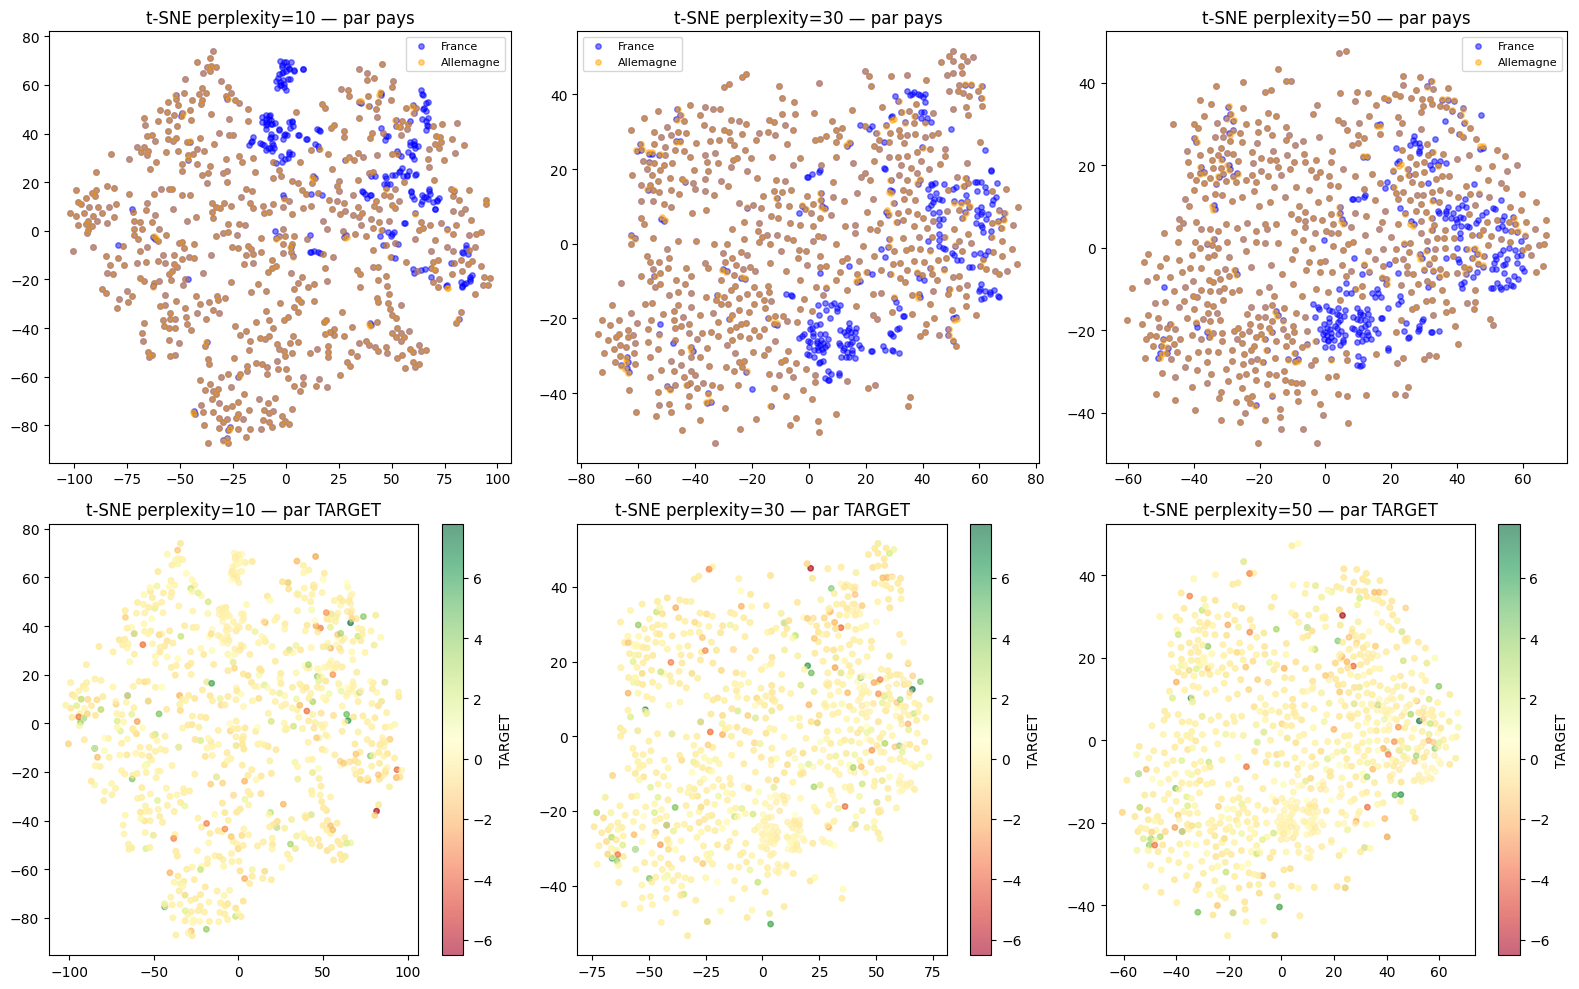

In [35]:
from sklearn.manifold import TSNE

# Redéfinition au cas où la variable a été écrasée
country = x_train[['ID','COUNTRY']].set_index('ID').loc[X_sel.index, 'COUNTRY']

X_pca_50 = PCA(n_components=min(50, X_sel.shape[1]),
               random_state=42).fit_transform(X_sel)

perplexities = [10, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col, perp in enumerate(perplexities):
    tsne = TSNE(n_components=2, perplexity=perp,
                max_iter=1000, learning_rate='auto',
                init='pca', random_state=42)
    X_tsne = tsne.fit_transform(X_pca_50)

    for pays, couleur, label in [('FR', 'blue', 'France'), ('DE', 'orange', 'Allemagne')]:
        mask = country.values == pays
        axes[0, col].scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                             c=couleur, alpha=0.5, s=15, label=label)
    axes[0, col].set_title(f't-SNE perplexity={perp} — par pays')
    axes[0, col].legend(fontsize=8)

    sc = axes[1, col].scatter(X_tsne[:, 0], X_tsne[:, 1],
                               c=target, cmap='RdYlGn', alpha=0.6, s=15)
    plt.colorbar(sc, ax=axes[1, col], label='TARGET')
    axes[1, col].set_title(f't-SNE perplexity={perp} — par TARGET')

plt.tight_layout()
plt.show()


**Ligne 1 - Coloré par pays**
La France forme un cluster (Nord / Est en bleu) tandis que l'Allemagne est très dispersée dans l'espace. Cela signifie que les jours FR ont des profils similaires entre eux tandis que les jours DE sont plus hétérogènes

**Ligne 2 - Coloré par Target**
Par de gradient spatial clair. Le Target est difficile à prédire.

### Séparation au sein des pays

FR : 851 obs x 42 features
DE : 643 obs x 43 features
France : 23 composantes pour 95% variance
Allemagne : 22 composantes pour 95% variance


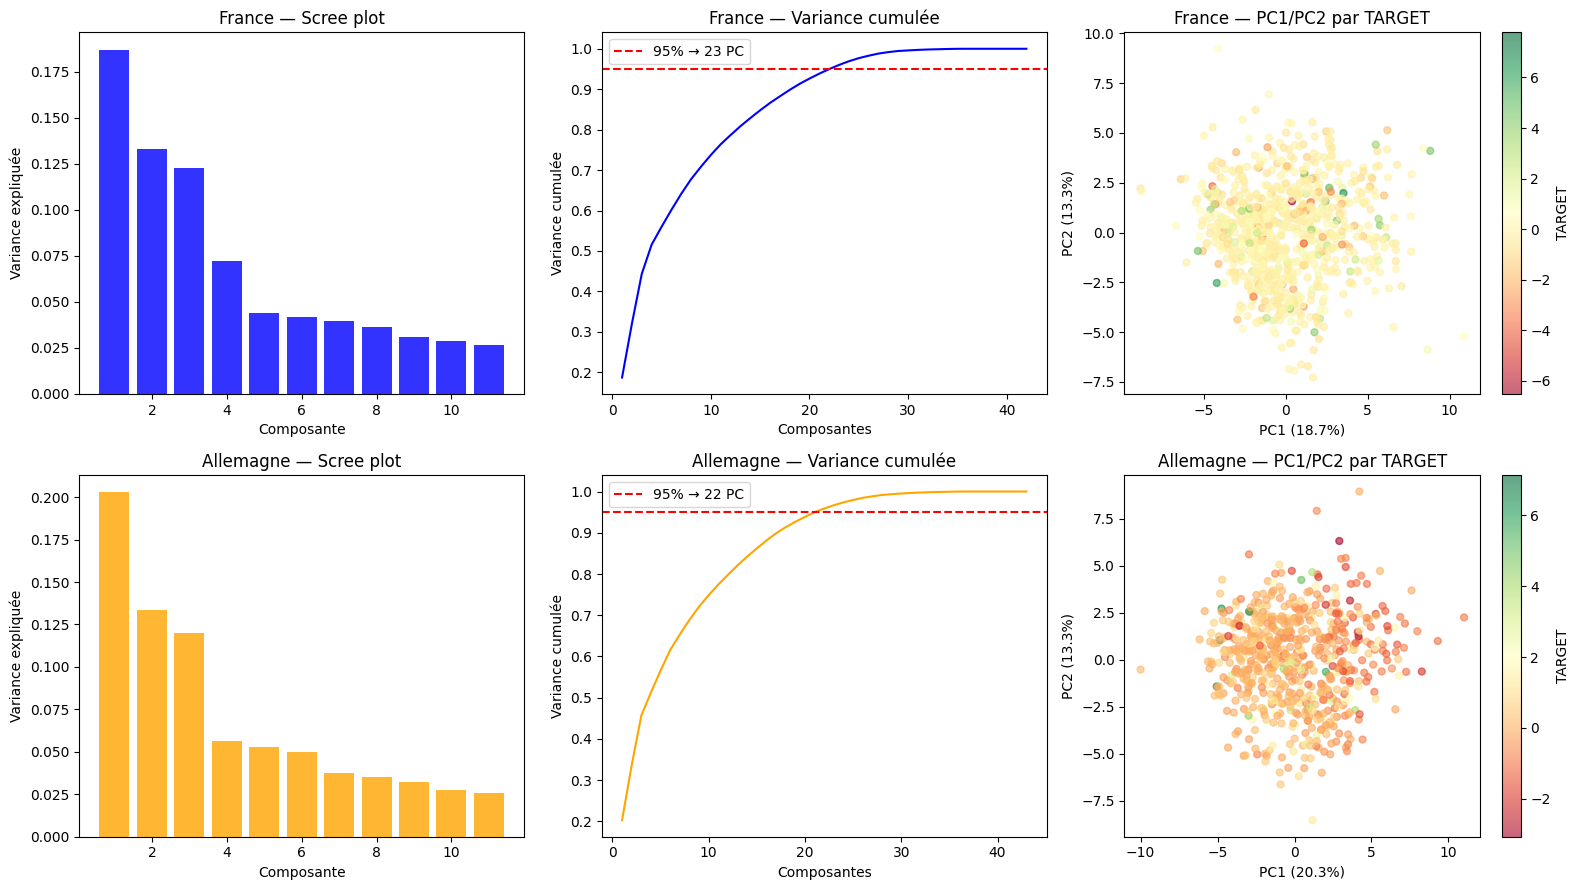

In [ ]:
# Séparation des features par pays
SHARED_FEATS = [f for f in selected_features_perm if not f.startswith('FR_') and not f.startswith('DE_')]
FR_FEATS = [f for f in selected_features_perm if f.startswith('FR_')] + SHARED_FEATS
DE_FEATS = [f for f in selected_features_perm if f.startswith('DE_')] + SHARED_FEATS

mask_fr = country.values == 'FR'
mask_de = country.values == 'DE'

X_fr = X_sel[mask_fr][FR_FEATS]
X_de = X_sel[mask_de][DE_FEATS]
y_fr = y_cv.loc[X_sel.index[mask_fr]].values
y_de = y_cv.loc[X_sel.index[mask_de]].values

print(f"FR : {X_fr.shape[0]} obs x {X_fr.shape[1]} features")
print(f"DE : {X_de.shape[0]} obs x {X_de.shape[1]} features")

# ACP par pays
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row, (X_c, y_c, label, color) in enumerate([
    (X_fr, y_fr, 'France', 'blue'),
    (X_de, y_de, 'Allemagne', 'orange'),
]):
    pca_c = PCA()
    Xp = pca_c.fit_transform(X_c)
    ev = pca_c.explained_variance_ratio_
    cumul_c = np.cumsum(ev)
    n95_c = np.argmax(cumul_c >= 0.95) + 1

    axes[row, 0].bar(range(1, min(12, len(ev)+1)), ev[:11], color=color, alpha=0.8)
    axes[row, 0].set_xlabel('Composante')
    axes[row, 0].set_ylabel('Variance expliquée')
    axes[row, 0].set_title(f'{label} — Scree plot')

    axes[row, 1].plot(range(1, len(cumul_c)+1), cumul_c, color=color)
    axes[row, 1].axhline(0.95, color='red', linestyle='--', label=f'95% → {n95_c} PC')
    axes[row, 1].set_xlabel('Composantes')
    axes[row, 1].set_ylabel('Variance cumulée')
    axes[row, 1].set_title(f'{label} — Variance cumulée')
    axes[row, 1].legend()

    sc = axes[row, 2].scatter(Xp[:, 0], Xp[:, 1], c=y_c, cmap='RdYlGn', alpha=0.6, s=25)
    plt.colorbar(sc, ax=axes[row, 2], label='TARGET')
    axes[row, 2].set_xlabel(f'PC1 ({ev[0]:.1%})')
    axes[row, 2].set_ylabel(f'PC2 ({ev[1]:.1%})')
    axes[row, 2].set_title(f'{label} — PC1/PC2 par TARGET')

    print(f"{label} : {n95_c} composantes pour 95% variance")
    if label == 'France':
        pca_fr, X_pca_fr, n95_fr = pca_c, Xp, n95_c
    else:
        pca_de, X_pca_de, n95_de = pca_c, Xp, n95_c

plt.tight_layout()
plt.show()


Les deux ACP par pays confirment que 22-23 dimensions sont nécessaires pour décrire 95% de la variance (le signal est dans de nombreuses directions). Le TARGET n'est pas capturé par les 2 premières composantes dans aucun des deux pays, ce qui justifie d'utiliser toutes les composantes (pas seulement PC1/PC2) comme input pour le clustering KMeans/GMM qui suit.



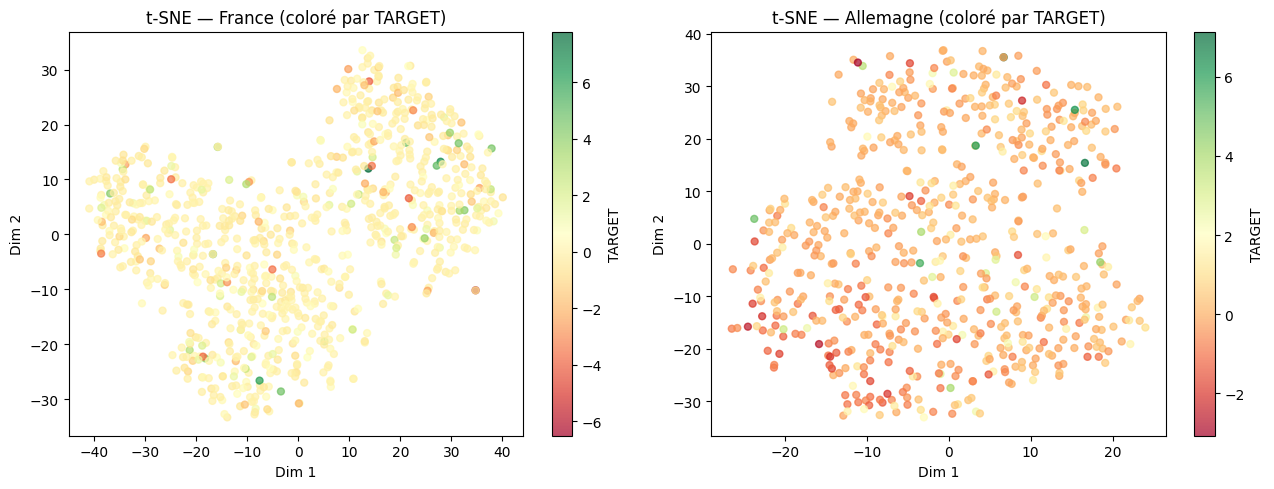

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, X_c, y_c, label in [
    (axes[0], X_fr, y_fr, 'France'),
    (axes[1], X_de, y_de, 'Allemagne'),
]:
    tsne_c = TSNE(n_components=2, perplexity=30,
                  max_iter=1000, learning_rate='auto',
                  init='pca', random_state=42)
    Xt = tsne_c.fit_transform(X_c)

    sc = ax.scatter(Xt[:, 0], Xt[:, 1], c=y_c, cmap='RdYlGn', alpha=0.7, s=25)
    plt.colorbar(sc, ax=ax, label='TARGET')
    ax.set_title(f't-SNE — {label} (coloré par TARGET)')
    ax.set_xlabel('Dim 1')
    ax.set_ylabel('Dim 2')

plt.tight_layout()
plt.show()


Le t-SNE par pays confirme et nuance les résultats précédents :

**France** : structure quasi-aléatoire → signal prix très difficile à capturer, modèle non supervisé limité

**Allemagne** : légère ségrégation spatiale par TARGET → des régimes de marché distincts existent, le clustering a plus de sens pour DE
En pratique, cela suggère que le clustering sera plus utile pour DE que pour FR, et que des modèles séparés par pays restent justifiés.

### Interprétation économique des composantes

In [38]:
# Interprétation économique des composantes
for label, pca_c, feats in [('France', pca_fr, FR_FEATS), ('Allemagne', pca_de, DE_FEATS)]:

    ev = pca_c.explained_variance_ratio_
    loadings = pd.DataFrame(pca_c.components_[:3].T,
                            index=feats, columns=['PC1','PC2','PC3'])

    print(f"\n{label.upper()}")
    print(f"Les 3 premières composantes expliquent {ev[:3].sum():.1%} de la variance totale.\n")

    for pc in ['PC1','PC2','PC3']:
        idx  = int(pc[2:]) - 1
        top  = loadings[pc].abs().nlargest(5)

        print(f"  {pc} ({ev[idx]:.1%} de la variance)")
        for feat in top.index:
            val      = loadings.loc[feat, pc]
            sens     = "positivement" if val > 0 else "négativement"
            print(f"    {feat} contribue {sens} ({abs(val):.3f})")
        print()

# Matrices réduites pour le clustering
pca_fr_final = PCA(n_components=n95_fr, random_state=42)
pca_de_final = PCA(n_components=n95_de, random_state=42)

X_cluster_fr = pca_fr_final.fit_transform(X_fr)
X_cluster_de = pca_de_final.fit_transform(X_de)

print("Matrices prêtes pour le clustering :")
print(f"  France     : {X_fr.shape[1]} features réduits à {n95_fr} composantes  {X_cluster_fr.shape}")
print(f"  Allemagne  : {X_de.shape[1]} features réduits à {n95_de} composantes  {X_cluster_de.shape}")



FRANCE
Les 3 premières composantes expliquent 44.3% de la variance totale.

  PC1 (18.7% de la variance)
    FR_RESIDUAL_LOAD contribue positivement (0.298)
    FR_CONSUMPTION contribue positivement (0.296)
    FR_GAS contribue positivement (0.290)
    FR_DE_EXCHANGE contribue négativement (0.257)
    NET_FLOW_DE_TO_FR contribue positivement (0.257)

  PC2 (13.3% de la variance)
    FR_NUCLEAR contribue positivement (0.322)
    FR_NET_BALANCE contribue positivement (0.297)
    FR_NET_EXPORT contribue positivement (0.297)
    FR_TRADE_BALANCE contribue positivement (0.297)
    FR_NET_IMPORT contribue négativement (0.297)

  PC3 (12.3% de la variance)
    FOSSIL_COST_INDEX contribue positivement (0.390)
    CARBON_RET contribue positivement (0.381)
    COAL_CARBON_COST contribue positivement (0.374)
    GAS_CARBON_COST contribue positivement (0.355)
    COAL_RET contribue positivement (0.317)


ALLEMAGNE
Les 3 premières composantes expliquent 45.6% de la variance totale.

  PC1 (20.3% d

## 6.2) KMeans

### 6.2.1) Ajout des features

Nous allons utiliser un kmeans pour regrouper nos données en cluster et leur ajouter des données qui pourraient être utiles dans notre analyse. 

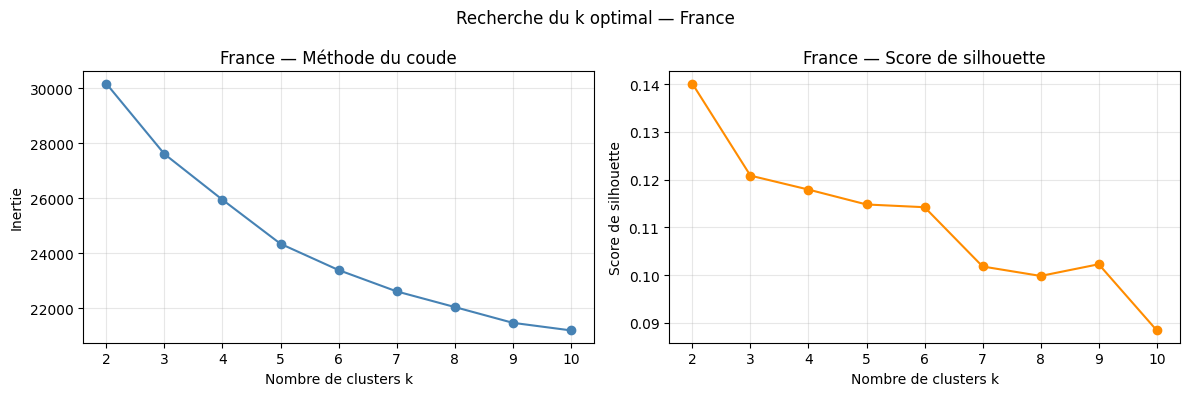

France : meilleur k selon silhouette = 2 (score = 0.140)


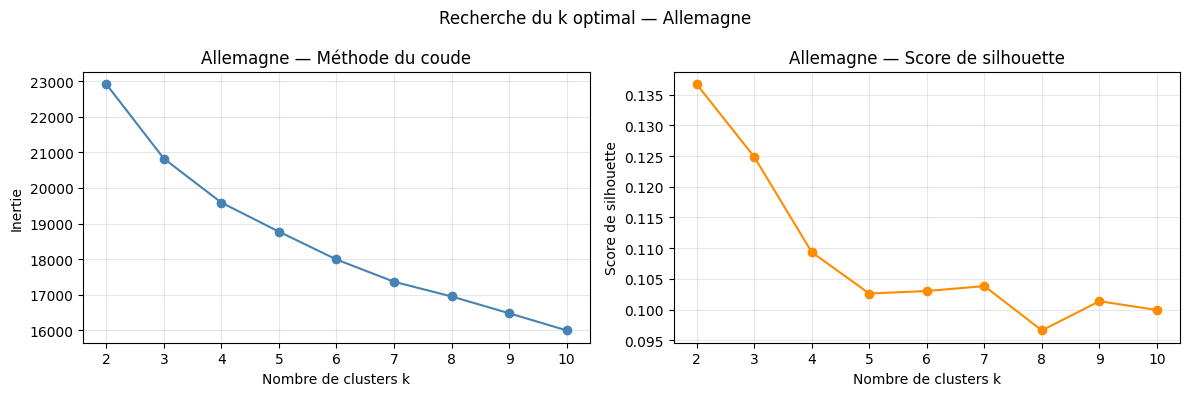

Allemagne : meilleur k selon silhouette = 2 (score = 0.137)


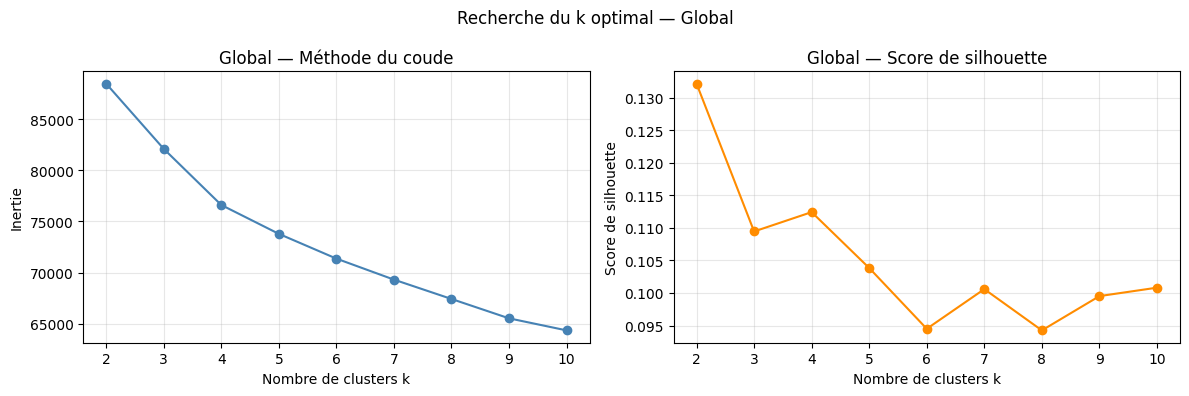

Global : meilleur k selon silhouette = 2 (score = 0.132)


In [43]:
n95 = np.argmax(variance_cumulee >= 0.95) + 1
pca_all_final = PCA(n_components=n95, random_state=42)
X_cluster_all = pca_all_final.fit_transform(X_sel)

def find_k_opt(X, label, k_range=range(2,11)):
    inerties    = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        inerties.append(km.inertia_)
        silhouettes.append(silhouette_score(X, km.labels_))

    # Graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Coude
    axes[0].plot(k_range, inerties, 'o-', color='steelblue')
    axes[0].set(xlabel='Nombre de clusters k', ylabel='Inertie',
                title=f'{label} — Méthode du coude')
    axes[0].grid(True, alpha=0.3)

    # Silhouette
    axes[1].plot(k_range, silhouettes, 'o-', color='darkorange')
    axes[1].set(xlabel='Nombre de clusters k', ylabel='Score de silhouette',
                title=f'{label} — Score de silhouette')
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Recherche du k optimal — {label}', fontsize=12)
    plt.tight_layout()
    plt.show()

    k_best = k_range[np.argmax(silhouettes)]
    print(f"{label} : meilleur k selon silhouette = {k_best} "
          f"(score = {max(silhouettes):.3f})")
    return k_best

k_best_fr = find_k_opt(X_cluster_fr, 'France')
k_best_de = find_k_opt(X_cluster_de, 'Allemagne')
k_best_all = find_k_opt(X_cluster_all, 'Global')


Les résultats confirment nos attentes : les données ne présentent pas de structures en clusters forte. 

**Score du coude** Les courbes (méthode du coude) décroissent sans rupture franche.

**Score de silhouette** Les scores sont tous inférieur à 0.25 ce qui est considéré comme faible.

In [47]:
km_fr  = KMeans(n_clusters=k_best_fr,  random_state=42, n_init=10)
km_de  = KMeans(n_clusters=k_best_de,  random_state=42, n_init=10)
km_all = KMeans(n_clusters=k_best_all, random_state=42, n_init=10)

labels_fr  = km_fr.fit_predict(X_pca_fr)
labels_de  = km_de.fit_predict(X_pca_de)
labels_all = km_all.fit_predict(X_cluster_all)

print(f"France — répartition : {pd.Series(labels_fr).value_counts().sort_index().to_dict()}")
print(f"Allemagne — répartition : {pd.Series(labels_de).value_counts().sort_index().to_dict()}")
print(f"Global — répartition : {pd.Series(labels_all).value_counts().sort_index().to_dict()}")

for label, X_c, labels, feats, y_c in [
    ('France', X_fr,  labels_fr,  FR_FEATS, y_fr),
    ('Allemagne', X_de,  labels_de,  DE_FEATS, y_de),
    ('Global', X_sel, labels_all, selected_features_perm,
                  y_cv.loc[X_sel.index].values),
]:
    df_c = pd.DataFrame(X_c.values, columns=feats)
    df_c['cluster'] = labels
    df_c['TARGET']  = y_c

    print(f"\n{label.upper()}")
    print(df_c.groupby('cluster')[['TARGET'] + feats[:5]].mean().round(3).to_string())
    print()


France — répartition : {0: 334, 1: 517}
Allemagne — répartition : {0: 279, 1: 364}
Global — répartition : {0: 597, 1: 897}

FRANCE
         TARGET  FR_WIND_SOLAR_PROD  FR_WIND_x_WINDPOW  FR_GAS_COST_x_PROD  FR_WINDPOW  FR_GAS
cluster                                                                                       
0         0.043              -0.321             -0.179              -0.017       0.443   0.807
1         0.048               0.070              0.101              -0.015      -0.346  -0.524


ALLEMAGNE
         TARGET  DE_WINDPOW  DE_RESIDUAL_LOAD  DE_LIGNITE  DE_WIND_SOLAR_PROD  DE_WIND
cluster                                                                               
0        -0.019       0.789            -0.348      -0.116               0.178    0.451
1         0.276      -0.591             0.130      -0.272              -0.033   -0.091


GLOBAL
         TARGET  COUNTRY_FR  DE_WINDPOW  COUNTRY_DE  FR_WIND_SOLAR_PROD  DE_RESIDUAL_LOAD
cluster                       

**Allemagne** :
On remarque deux régimes (éolien et thermique). L'écart de ~0.30 est cohérent avec le merit order effect : les renouvelables évincent les centrales thermiques et font baisser les prix spot. Le clustering capte une structure économique réelle.

**France** :
Ecart de TARGET quasi nul entre clusters. Le nucléaire, à coût marginal fixe, absorbe les variations de renouvelables et de gaz — le prix français y est peu sensible. Cela explique les scores CV plus faibles pour la France (≈ 0.14 vs 0.35 pour l'Allemagne).

**Global** : signal dilué par le mélange des deux pays. 

In [52]:
day_id_map = x_train[['ID', 'DAY_ID']].set_index('ID')
grp_fr = day_id_map.loc[X_sel.index[mask_fr], 'DAY_ID'].values
grp_de = day_id_map.loc[X_sel.index[mask_de], 'DAY_ID'].values


ridge = RidgeCV(alphas=np.logspace(-4, 4, 200), cv=10)
gkf   = GroupKFold(n_splits=5)
y_all_vals = y_cv.loc[X_sel.index].values

cases = [
    ('France',    X_fr,              labels_fr,  y_fr,       grp_fr),
    ('Allemagne', X_de,              labels_de,  y_de,       grp_de),
    ('Global',    X_sel.values, labels_all, y_all_vals, groups),
]

for label, X_c, labels, y_c, grp in cases:
    splits = list(gkf.split(X_c, y_c, groups=grp))
    cv_kw  = dict(cv=splits, scoring=spearman_scorer, n_jobs=-1)

    score_sans  = cross_val_score(ridge, X_c, y_c, **cv_kw)
    cluster_oh  = pd.get_dummies(labels, prefix='cluster').values
    score_avec  = cross_val_score(ridge, np.hstack([X_c, cluster_oh]), y_c, **cv_kw)

    print(f"{label}")
    print(f"  Sans cluster : {score_sans.mean():.4f} ± {score_sans.std():.4f}")
    print(f"  Avec cluster : {score_avec.mean():.4f} ± {score_avec.std():.4f}")
    print(f"  Gain KMeans  : {score_avec.mean() - score_sans.mean():+.4f}\n")


France
  Sans cluster : 0.1300 ± 0.1012
  Avec cluster : 0.1293 ± 0.1013
  Gain KMeans  : -0.0007

Allemagne
  Sans cluster : 0.3485 ± 0.0417
  Avec cluster : 0.3481 ± 0.0410
  Gain KMeans  : -0.0004

Global
  Sans cluster : 0.2114 ± 0.0304
  Avec cluster : 0.2114 ± 0.0304
  Gain KMeans  : -0.0000

